# Polynomial Regression

When a data more complex than a straight line, then we add powers of each feature as new features, then train a linear model on this extended set of features. This is called Polynomial Regression. 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
m = 100 
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

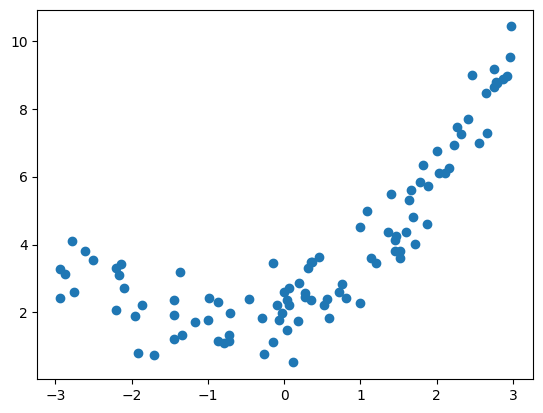

In [5]:
plt.scatter(X, y) 
plt.show()

In [6]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-2.9337164])

In [7]:
X_poly[0]

array([-2.9337164 ,  8.60669192])

Here we used PolynomialFeatures class to add square of features as new features. 

In [8]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.06302612]), array([[0.95637468, 0.51834302]]))

#### Note: 
PolynomialFeatures with degree $d$ will transform an array with $n$ features into an array with $\frac {(n+d)!}{d!n!}$. 

## Learning Curves

These are plots of the model's performance on training set and the validation set as a function of the training set size 

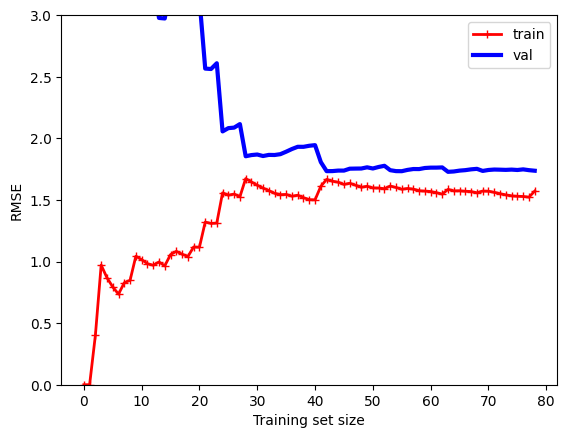

In [33]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)): 
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.ylabel("RMSE")
    plt.xlabel("Training set size")
    plt.ylim(0, 3)
    plt.legend()

lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

### In the case of Linear Model
#### Training set, 
- When the training set size is small, it's easy for the model to overfit the data.
- As the size increases, the error decreases until it eventually plateaus.

#### Validation set, 
- When the model is trained on few instances, it is not able to generalize properly, which leads to huge validation error in the beginning.
- As the model is trained on more examples, it learns and the validation error goes down.

A straight line cannot do a good job, therefore the error in both cases plateaus to some value. 
This is an example of underfitting of data. 

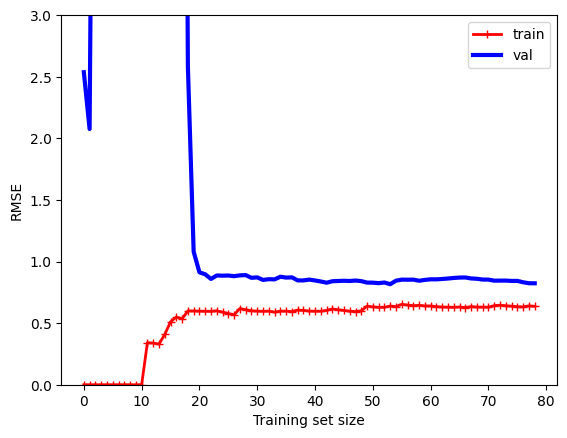

In [36]:
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)), 
    ("lin_reg", LinearRegression())
])

plot_learning_curves(polynomial_regression, X, y)

### In the case of a 10th Degree Polynomial

The curves look similar, however there are two important differences: 
- The error on training data is much lower than with Linear Regression.
- There is a gap between the curves. Which means the model performs better on training data than validation data, which is the case with overfitted data.

If a larger dataset would be used, the curves would eventually get closer. This is also one way of improving an overfitted model. 

## Bias/Variance Trade-off
A model's generalization error can be expressed as the sum of three very different errors: 
1. **Bias**: This is due to wrong assumptions, such as assuming that the data is linear when it's actually quadratic. A high bias model is likely to underfit the training data.
2. **Variance**: This is due to model's excessive sensitivity to small variations in the training data. A model with high degree of freedom (such as high degree polynomial model) is likely to have high variance and overfit the data.
3. **Irreducible error**: This is due to noise in the data itself. This can only be reduced by cleaning up the data.

Increasing a model's complexity generally increases it's variance and reduces it's bias. The converse is also true, and hence it's called a trade-off. 

## Regularized Linear Models 
A simple way to regularize a polynomial model isto reduce the number of polynomial degrees. For a linear model, it is typically done by constraining the weights of the model. 


### Ridge Regression

- Also called Tikhonov regularization.
- It is a regularized version of Linear Regression.
- A regularization term (equal to $\alpha\sum_{i=1}^{n} {\theta_i^2}$) is added to cost function.
- This forces the algorithm to fit the data and also keep the weights as small as possible.
- This regularization term should only be added during training. Once the model is trained, it's unregularized performance measure is used to evaluate it's performance.

Hyperparameter $\alpha$ controls how much you want to regularize the model.
- If $\alpha$ is set to zero, then Ridge Regression is just Linear Regression.
- If $\alpha$ is large, then all weights end up close to zero (regularization term dominates) and it results in the regression line becoming the $y=\theta_0$ (intercept, since the bias term $\theta_0$ is not included in regularization). To minimize the cost function, $\theta_0$ becomes the mean (flat line closest to all data points).

**Ridge Regression cost function**: $$J(\boldsymbol {\theta}) = MSE(\boldsymbol {\theta}) + \alpha \frac {1} {2} \sum_{i=1}^{n} {\theta_i^2}$$

If we define $\textbf {w}$ as the vector of feature weights ($\theta_1$ to $\theta_n$), then the regularization term becomes $\frac{1}{2}(\lVert \textbf{w} \rVert_2)^2$. For gradient descent, $\alpha\textbf{w}$ is added to the MSE gradient vector. 
$\lVert \textbf{w} \rVert_2$ represents the $l_2$ norm of the weight vector. 

**Note**: It is important to scale the data before performing Ridge Regression or any other regularized model as they're sensitive to the scale of input features.

**Ridge Regression closed-form solution**: $$\hat {\boldsymbol {\theta}} = (\textbf{X}^T\textbf{X} + \alpha\textbf{A})^{-1} \  \textbf{X}^T \  \textbf{y}$$

#### Ridge Regression using Scikit-Learn (using closed-form solution)

In [39]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1, solver="cholesky") # a variant that uses matrix factorization technique by A. L. Cholesky
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([5.14453661])

#### Using Stochastic Gradient Descent

In [40]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty="l2") # indicates addition of l2 norm (regularization term)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([5.1158898])

### Lasso Regression

_Least Absolute Shrinkage and Selection Operator_ (LASSO) Regression is another regularized version of Linear Regression. It uses $l_1$ norm of weight vector instead of half of square of $l_2$ norm like in Ridge Regression. 

**Lasso Regression cost function**: $$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \sum_{i=1}^{n} {\lvert \theta_{i} \rvert}$$

- Lasso Regression tends to eliminate less important weights (set to zero).
- To prevent gradient descent from bouncing around the optimum in lasso regression, we decrease the learning rate gradually during training. This won't stop the bouncing around, but steps will get smaller so it would converge.

**Lasso Regression subgradient vector**: $$g(\boldsymbol{\theta}, J) = \nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) + \alpha 
\begin{pmatrix}
\text{sign}(\theta_1) \\
\text{sign}(\theta_2) \\
\vdots \\
\text{sign}(\theta_n)
\end{pmatrix}
\quad \text{where} \quad \text{sign}(\theta_i) = 
\begin{cases} 
-1 & \text{if } \theta_i < 0 \\ 
0 & \text{if } \theta_i = 0 \\ 
+1 & \text{if } \theta_i > 0 
\end{cases}$$

#### Scikit-Learn example

In [42]:
from sklearn.linear_model import Lasso 

lasso_reg = Lasso(alpha=0.1) # or SGDRegressor with penalty="l1"
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([5.1076204])

## Elastic Net 
It is a middle ground between Ridge and Lasso Regressions. The regularization term is a mix of Ridge and Lasso's regularization terms, and you can control the mix ratio $r$. 
When $r = 0$, Elastic Net is equivalent to Ridge Regression, 
and when $r = 1$, it is equivalent to Lasso Regression. 

**Elastic Net cost function**: $$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + r \alpha \sum_{i=1}^{n} {\lvert \theta_i \rvert} + \frac {1-r}{2} \alpha \sum_{i=1}^{n} {\theta_i^2}$$

It is almost always preferable to have some regularization, so plain Linear Regression should be avoided. Ridge is good for default, but if there is a suspicion that only some features are useful, then Lasso or Elastic Net should be preferred. In general, Elastic Net is preferred over Lasso as Lasso behaves erratically when number of features is greater than the number of training instances or when several features are strongly correlated. 

#### Scikit-Learn example

In [43]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([5.10665019])

## Early Stopping
Another way to regularize algorithms like Gradient Descent is to stop training as soon as the validation error reaches a minimum. This is called early stopping. 
With Stochastic/Mini-batch GD, the curves are not so smooth and it could be difficult to know if we have reached minimum. In this case, we can stop only after the validation error has been above the minimum for some time, then roll back the model parameters to the point where the validation error was minimum. 